Candidate ID: 71131

ST456 2026 WT Assessment 1

## 0. Set up

Imports used in the problems below

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import functools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten, BatchNormalization, RandomFlip, RandomRotation, RandomTranslation, GlobalAveragePooling2D
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping
import os

Data loading function

In [2]:
def dataloading(batch_size=32, mean=tf.constant([0.4914, 0.4822, 0.4465]), std=tf.constant([0.2023, 0.1994, 0.2010])):
    (x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
    x_train, x_test = x_train.astype(np.float32) / 255.0, x_test.astype(np.float32) / 255.0

    # apply normalization
    x_train = (x_train - mean) / std
    x_test = (x_test - mean) / std

    # Reserve 10,000 samples for validation.
    x_val = x_train[-10000:]
    y_val = y_train[-10000:]
    x_train = x_train[:-10000]
    y_train = y_train[:-10000]

    # Prepare the training dataset.
    train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train))
    train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

    # Prepare the validation dataset.
    val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val))
    val_dataset = val_dataset.batch(batch_size)

    test_dataset = tf.data.Dataset.from_tensor_slices((x_test, y_test)).batch(batch_size)

    for loader in [train_dataset, val_dataset, test_dataset]:
        loader.mean, loader.std = mean, std
        loader.data_max = tf.reshape((1. - mean) / std, (1, 1, 1, -1))
        loader.data_min = tf.reshape((0. - mean) / std, (1, 1, 1, -1))

    return train_dataset, val_dataset, test_dataset

In [3]:
### Setting hyperperameters
minibatch_size = 128
learning_rt = 0.001
n_epochs = 100

In [4]:
### Loading the CIFAR10 dataset usign the data loader
train_data, val_data, test_data = dataloading(batch_size=minibatch_size)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [5]:
### To save weights for evaluation later

from google.colab import drive
drive.mount('/content/drive')

# Folder for the no dropout version in P1
folder_path = '/content/drive/MyDrive/Colab Notebooks/ST456 Deep Learning/Assessment 1/No Dropout'
os.makedirs(folder_path, exist_ok=True)

# Folder for the dropout version in P1
folder_path_drop = '/content/drive/MyDrive/Colab Notebooks/ST456 Deep Learning/Assessment 1/Dropout'
os.makedirs(folder_path_drop, exist_ok=True)

# Folder to save the weights for the best model in P2 to be used in P3
folder_path_p2_best = '/content/drive/MyDrive/Colab Notebooks/ST456 Deep Learning/Assessment 1/P2 Best Model'
os.makedirs(folder_path_p2_best, exist_ok=True)

Mounted at /content/drive


# **P1. CIFAR10 CNN: training using minibatch gradient descent algorithms**

Implement a CNN architecture that consists of 3 convolutional layers followed by a fully connected layer of 1000 units.

Each convolutional layer consists of a sublayer of 5x5 convolutional filters with stride 1 followed by a sublayer of 2x2 max-pool units with stride 2. Each neuron applies ReLU activation function.

**Task:** Evaluate and plot the **average training loss per epoch** versus the number of epoches for the training dataset, for the following optimization algorithms:

- Mini-batch gradient descent
- Mini-batch AdaGrad
- Mini-batch RMSProp
- Mini-batch gradient descent with Nesterov’s momentum
- Mini-batch Adam

In addition, show the results by adding dropout. Comment the results.

---

**Hints:**
- A CIFAR10 data loader is provided in the assessment1 notebook.
- In order to reduce the training time when designing the network, you can try only using the first 50 mini-batches for each epoch.
- More specifically, at the beginning of each epoch, randomly shuffle the whole training dataset. Then, only iterate through the first 50 mini-batches for one epoch training.
- Training on Google Colab GPU is highly recommended. The training time on 1 GPU is roughly 1 minute per epoch.

In [5]:
### Identifying optimization algorithms/methods to compare
def my_optimizers(learning_rate=learning_rt):
    return [keras.optimizers.SGD(learning_rate=learning_rt), # SGD
            keras.optimizers.Adagrad(learning_rate=learning_rt), # Adagrad
            keras.optimizers.RMSprop(learning_rate=learning_rt), # RMSprop
            keras.optimizers.SGD(learning_rate=learning_rt, momentum=0.5, nesterov=True), # GD_NesterovMomentum
            keras.optimizers.Adam(learning_rate=learning_rt) # Adam
            ]

optimizer_names = ['SGD','Adagrad','RMSprop','GDNesterovMomentum','Adam']

### Build and compile the 5 models:
- The model includes:
  - 3 convolution blocks, each with a 5x5 convolution filter with stride 1 + a max-pool layer with 2x2 units and sstride 2, all with ReLU activation function
  - A flatten layer, followed by a fully connected layer of 1000 units
  - An "optional" dropout layer, used for the 2nd part of this analysis
  - The output layer with softmax activation function
- The model is compiled for each of the 5 optimization algorithms with Sparse Categorical Crossentropy loss, measuring for accuraacy

In [6]:
### Function to build and compile model
def build_compile(optimizer_name='SGD', use_dropout=False):

    ### Build model
    model = Sequential()

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(5,5), strides=1, input_shape=(32,32,3), padding='same', activation='relu', kernel_initializer='he_normal')) # Convolution filter 1
    model.add(MaxPooling2D(pool_size=(2,2), strides=2)) # Max-pool 1

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(5,5), strides=1, padding='same', activation='relu', kernel_initializer='he_normal')) # Convolution filter 2
    model.add(MaxPooling2D(pool_size=(2,2), strides=2)) # Max-pool 2

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(5,5), strides=1, padding='same', activation='relu', kernel_initializer='he_normal')) # Convolution filter 3
    model.add(MaxPooling2D(pool_size=(2,2), strides=2)) # Max-pool 3

    # Fully connected layer of 1000 units
    model.add(Flatten()) # need to flatten first
    model.add(Dense(1000, activation='relu', kernel_initializer='he_normal')) # fully connected dense layer

    # If Dropout is used:
    if use_dropout:
        model.add(keras.layers.Dropout(0.5)) # dropout layer for fully connected layer

    # Output layer
    model.add(Dense(10, activation='softmax'))


    ### Compile model: with a cross-entropy loss and specify the given optimizer
    model.compile(optimizer=optimizer_name, loss=keras.losses.SparseCategoricalCrossentropy, metrics=['accuracy'])

    ### Summary of model
    model.summary()
    return model

### Training the model:
The for loop below runs the model for each of the 5 optimizers and tracks their training and validation accuracies and losses, as well as the amount of time it takes to run each iteration.

The for loop below is for the model without the dropout layer.

There is also a section to store the weights for each of the optimizers, later used to evaluate the trained models against the test data.

In [ ]:
### Train model (no dropout)
  # Note: The code below has been adapted from the seminar file 'w03_OptimisationMNIST.ipynb' and updated for this project

# Two arrays for training and validation performance
hist_acc_nn = []
hist_val_acc_nn = []
hist_loss_nn = []
hist_val_loss_nn = []

# Tracking the run time for the code
start = time.time()

# For loop to iterate over the diferent optimizers and train the network using training and validation data
for item, name in zip(my_optimizers(learning_rt), optimizer_names):
    print("-----------------------------")
    print("Doing %s optimizer" %str(name))
    print("-----------------------------")

    # Get the model from our function above
    model = build_compile(optimizer_name = item) # each for loop iteration is for each optimizer

    # Train the model
    history = model.fit(train_data, validation_data=val_data, epochs=n_epochs)

    # Store the performance
    hist_acc_nn.append(history.history['accuracy'])
    hist_val_acc_nn.append(history.history['val_accuracy'])
    hist_loss_nn.append(history.history['loss'])
    hist_val_loss_nn.append(history.history['val_loss'])

    # Save the weights after this optimizer
    weights_filename = f'{folder_path}/p1_weights_nodropout_{name}.weights.h5'
    model.save_weights(weights_filename)
    print(f'Saved weights to {weights_filename}')

    print("-----------------------------")

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

-----------------------------
Doing SGD optimizer
-----------------------------


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     2,049,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,317,634 (8.84 MB)

 Trainable params: 2,317,634 (8.84 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1000)           │     2,049,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,317,634 (8.84 MB)

 Trainable params: 2,317,634 (8.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.3756 - loss: 1.7214 - val_accuracy: 0.5974 - val_loss: 1.1389
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6227 - loss: 1.0678 - val_accuracy: 0.6625 - val_loss: 0.9720
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7053 - loss: 0.8438 - val_accuracy: 0.6997 - val_loss: 0.8657
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.7623 - loss: 0.6784 - val_accuracy: 0.7163 - val_loss: 0.8911
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8088 - loss: 0.5428 - val_accuracy: 0.7244 - val_loss: 0.8853
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8619 - loss: 0.3902 - val_accuracy: 0.7248 - val_loss: 0.9813
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9046 - loss: 0.2721 - val_accuracy: 0.7199 - val_loss: 1.0996
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9304 - loss: 0.2008 - 

### Visualizing the plots for each optimizer's model (without dropout):
1. Average training loss per epoch vs # of epochs
2. Average validation loss per epoch vs # of epochs
3. Average training accuracy per epoch vs # of epochs
4. Average validation accuracy per epoch vs # of epochs

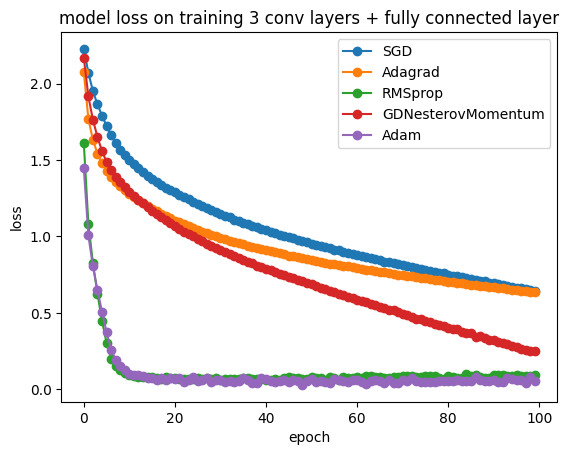

In [ ]:
### Plot: Average training loss per epoch vs # of epochs
for i in range(len(optimizer_names)):
    plt.plot(hist_loss_nn[i],'-o',label=str(optimizer_names[i]))
plt.title('model loss on training 3 conv layers + fully connected layer')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

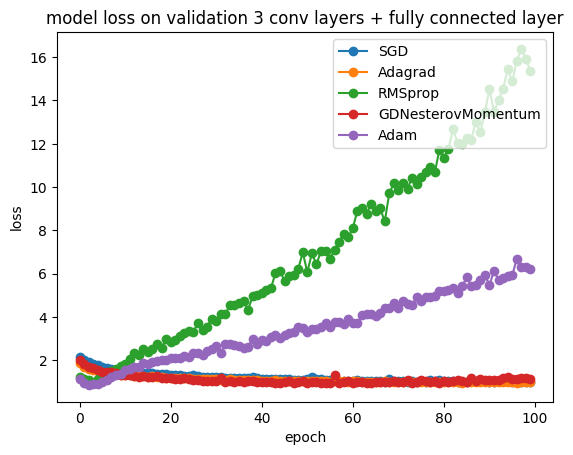

In [ ]:
### Plot: Average validation loss per epoch vs # of epochs
for i in range(len(optimizer_names)):
    plt.plot(hist_val_loss_nn[i],'-o', label=str(optimizer_names[i]))
plt.title('model loss on validation 3 conv layers + fully connected layer')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

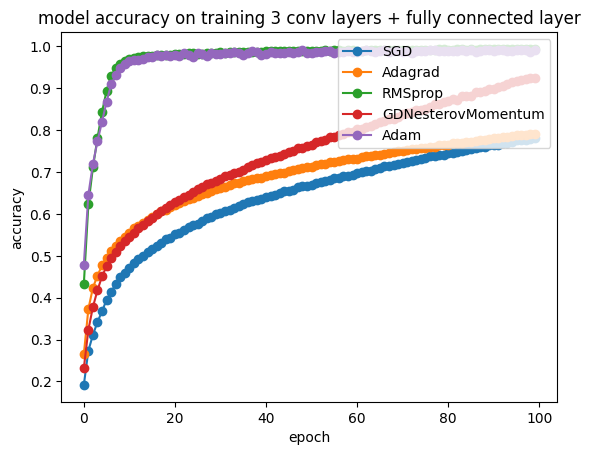

In [ ]:
### Plot: Average training accuracy per epoch vs # of epochs
for i in range(len(optimizer_names)):
    plt.plot(hist_acc_nn[i],'-o',label=str(optimizer_names[i]))
plt.title('model accuracy on training 3 conv layers + fully connected layer')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

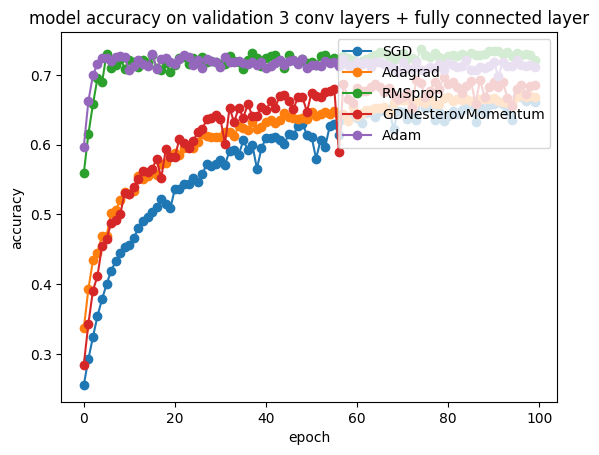

In [ ]:
### Plot: Average validation accuracy per epoch vs # of epochs
for i in range(len(optimizer_names)):
    plt.plot(hist_val_acc_nn[i],'-o',label=str(optimizer_names[i]))
plt.title('model accuracy on validation 3 conv layers + fully connected layer')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

### Evaluate the model:

The saved weights are called back and used to evaluate against the test data, observing the test accuracy and test loss.

In [ ]:
### Evaluate model
for item, name in zip(my_optimizers(learning_rt), optimizer_names): # calling back model
    # Get back the model and weights
    model = build_compile(optimizer_name=item) # re-instantiate the same model and compile it
    model.load_weights(f'{folder_path}/p1_weights_nodropout_{name}.weights.h5') # load the weights

    # Evaluate the model for accuracy and loss
    test_loss_score, test_acc_score = model.evaluate(test_data)
    print(f'{name} - Test accuracy: {test_acc_score:.4f}, Test loss: {test_loss_score:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     2,049,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,317,634 (8.84 MB)

 Trainable params: 2,317,634 (8.84 MB)

...

 Total params: 2,317,634 (8.84 MB)

 Trainable params: 2,317,634 (8.84 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 166ms/step - accuracy: 0.7126 - loss: 6.3049
Adam - Test accuracy: 0.7119, Test loss: 6.1127


### Results interpretation:

#### Training and validation performance:


| Optimizer                 | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss |
|---------------------------|------------------|--------------|--------------------|-----------------|
| SGD                       | 0.7840           | 0.6425       | 0.6609             | 1.0155          |
| Adagrad                   | 0.7931           | 0.6344       | 0.6687             | 0.9935          |
| RMSProp                   | 0.9932           | 0.1150       | 0.7215             | 15.3567         |
| Nesterov with Momentum    | 0.9244           | 0.2514       | 0.6853             | 1.1555          |
| Adam                      | 0.9916           | 0.0536       | 0.7112             | 6.2017          |

*Convergence of models:*

- RMSProp and Adam converge very quickly (after ~3-4 epochs) while GDNesterovMomentum, Adagrad, and SGD converge more gradually
- GDNesterovMomentum converges faster than Adagrad and SGD and more stably than RMSProp and Adam
- SGD and Adagrad continue to steadily improve over the 100 epochs, with some minor fluctuations

*Training and validation losses and accuracies:*
- Though RMSProp and Adam reach >99% training accuracy very quickly, their validation losses, which begin increasing after \~3-4 epochs, indicate they massively overfit, and by 100 epochs have very high losses (\~15.4 and \~6.2, respectively)
- GDNesterovMomentum, Adagrad, and SGD's training accuracies steadily grow, and by the 100th epoch, SGD's is nearly the same as Adagrad's, and they have lower and more stable validation losses, even with small fluctuations occurring
- GDNesterovMomentum, Adagrad, and SGD's  training losses also initially decrease quickly in the first ~10 epochs, then steadily decrease throughout the 100 epochs
- Validation accuracy is lower than training accuracy for all optimizers, with RMSProp and Adam slightly outperforming the other models at ~71-72%, but at the cost of overfitting, while SGD and Adagrad reach ~66% validation accuracies and GDNesterovMomentum above 68% validation accuracy

___

#### Test loss and accuracy:

| Optimizer              | Test Accuracy | Test Loss |
|------------------------|--------------|-----------|
| SGD                    | 0.6577       | 1.0187    |
| Adagrad                | 0.6622       | 1.0005    |
| RMSprop                | 0.7239       | 15.4529   |
| GDNesterovMomentum     | 0.6811       | 1.1541    |
| Adam                   | 0.7119       | 6.1127    |

- RMSProp and Adam had the best test accuracies (~72% and ~71%), but their extremely high test losses (15.5 and 6.1, respectively) indicate overfitting, confirming the validation loss explosion seen above
- GDNesterovMomentum has the highest among those three at 68%, but it is much more stable (1.15 loss)
- Adagrad has a test accuracy of 66.2%, and SGD at the lowest at 65.8%, but their low test losses (~1.0) indicate they are stable

### **Version with Dropout**

### Training the model:

Similar to above, the 5 models **with dropout** is run through the for loop, tracking training and testing accuracies and losses as well as saving the weights.

In [10]:
### Train the model (with dropout)
  # Note: The code below has been adapted from the seminar file 'w03_OptimisationMNIST.ipynb' and updated for this project

# Two arrays for training and validation performance
hist_acc_nn_drop = []
hist_val_acc_nn_drop = []
hist_loss_nn_drop = []
hist_val_loss_nn_drop = []

start = time.time()

# For loop to iterate over the diferent optimizers and train the network, using trainining and validation data
for item, name in zip(my_optimizers(learning_rt), optimizer_names):
    print("-----------------------------")
    print("Doing %s optimizer" %str(name))
    print("-----------------------------")

    keras.backend.clear_session()

    # Get the model from our function above
    model_drop = build_compile(optimizer_name = item, use_dropout=True) # each for loop iteration is for each optimizer, dropout included

    # Train the model
    history = model_drop.fit(train_data, validation_data=val_data, epochs=n_epochs)

    # Store the performance
    hist_acc_nn_drop.append(history.history['accuracy'])
    hist_val_acc_nn_drop.append(history.history['val_accuracy'])
    hist_loss_nn_drop.append(history.history['loss'])
    hist_val_loss_nn_drop.append(history.history['val_loss'])

    # Save the weights after this optimizer
    weights_filename = f'{folder_path_drop}/p1_weights_dropout_{name}.weights.h5'
    model_drop.save_weights(weights_filename)
    print(f'Saved weights to {weights_filename}')

    print("-----------------------------")

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

-----------------------------
Doing SGD optimizer
-----------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     2,049,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,317,634 (8.84 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1000)           │     2,049,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,317,634 (8.84 MB)

 Trainable params: 2,317,634 (8.84 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.3405 - loss: 1.8067 - val_accuracy: 0.5638 - val_loss: 1.2095
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.5872 - loss: 1.1647 - val_accuracy: 0.6462 - val_loss: 1.0043
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.6686 - loss: 0.9405 - val_accuracy: 0.6903 - val_loss: 0.8861
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7225 - loss: 0.7820 - val_accuracy: 0.7027 - val_loss: 0.8747
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7710 - loss: 0.6588 - val_accuracy: 0.7254 - val_loss: 0.8331
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8026 - loss: 0.5582 - val_accuracy: 0.7398 - val_loss: 0.8347
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8329 - loss: 0.4678 - val_accuracy: 0.7256 - val_loss: 0.9266
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8640 - loss: 0.3825 -

### Visualizing the plots for each optimizer's model (with dropout):
1. Average training loss per epoch vs # of epochs
2. Average validation loss per epoch vs # of epochs
3. Average training accuracy per epoch vs # of epochs
4. Average validation accuracy per epoch vs # of epochs

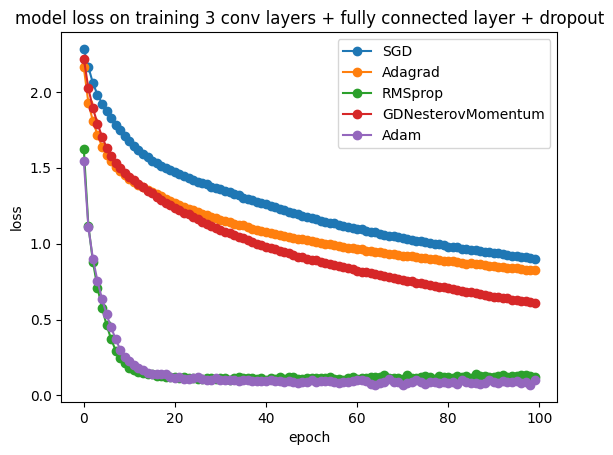

In [11]:
### Visualize model: history for training loss (with dropout)

for i in range(len(optimizer_names)):
    plt.plot(hist_loss_nn_drop[i],'-o',label=str(optimizer_names[i]))
plt.title('model loss on training 3 conv layers + fully connected layer + dropout')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

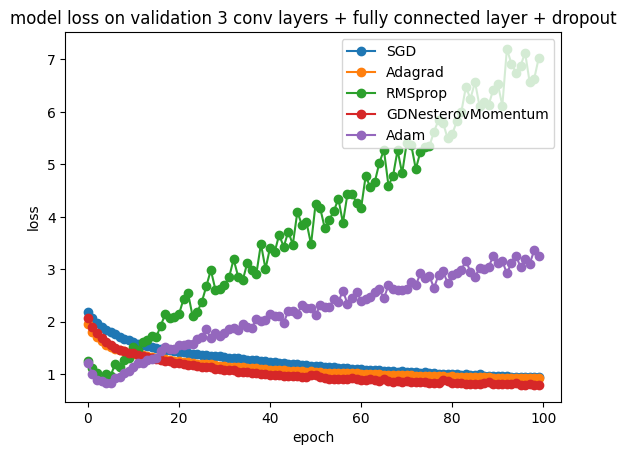

In [12]:
### Visualize model: history for validation loss (with dropout)

for i in range(len(optimizer_names)):
    plt.plot(hist_val_loss_nn_drop[i],'-o', label=str(optimizer_names[i]))
plt.title('model loss on validation 3 conv layers + fully connected layer + dropout')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

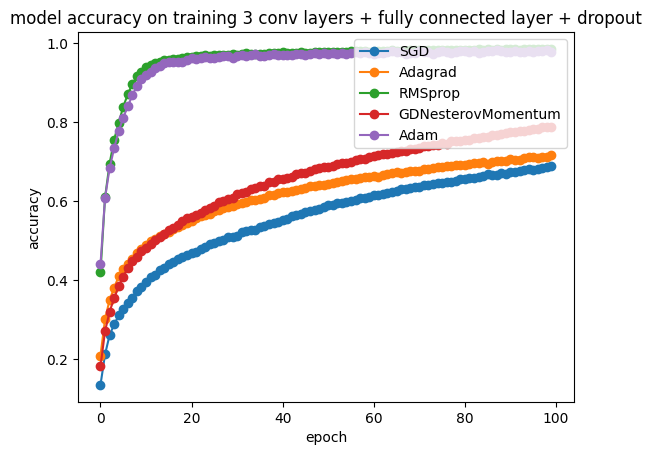

In [13]:
### Visualize model: history for training accuracy (with dropout)
for i in range(len(optimizer_names)):
    plt.plot(hist_acc_nn_drop[i],'-o',label=str(optimizer_names[i]))
plt.title('model accuracy on training 3 conv layers + fully connected layer + dropout')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

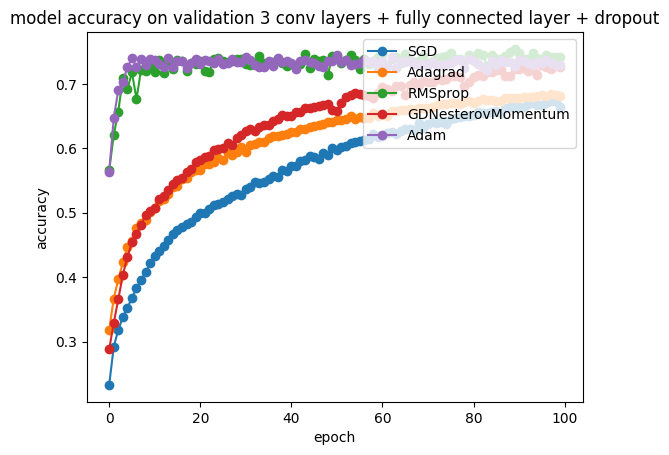

In [14]:
### Visualize model: history for training accuracy (with dropout)
for i in range(len(optimizer_names)):
    plt.plot(hist_val_acc_nn_drop[i],'-o',label=str(optimizer_names[i]))
plt.title('model accuracy on validation 3 conv layers + fully connected layer + dropout')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(loc='upper right')
plt.show()

### Evaluate the model:

Similar to above, the saved weights are called back and used to evaluate against the test data, observing the test accuracy and test loss.

In [16]:
### Evaluate model
for item, name in zip(my_optimizers(learning_rt), optimizer_names): # calling back model
    # Get back the model and weights
    model_drop = build_compile(optimizer_name=item, use_dropout=True) # re-instantiate the same model and compile it
    model_drop.load_weights(f'{folder_path_drop}/p1_weights_nodropout_{name}.weights.h5') # load the weights

    # Evaluate the model for accuracy and loss
    test_loss_score, test_acc_score = model_drop.evaluate(test_data)
    print(f'{name} - Test accuracy: {test_acc_score:.4f}, Test loss: {test_loss_score:.4f}')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1000)           │     2,049,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │        10,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,317,634 (8.84 MB)

 Trainable params: 2,317,634 (8.84 MB)

...

 Total params: 2,317,634 (8.84 MB)

 Trainable params: 2,317,634 (8.84 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.7234 - loss: 3.3898
Adam - Test accuracy: 0.7228, Test loss: 3.3103


### Results interpretation for no dropout:

#### Training and validation loss and accuracy:

| Optimizer              | Training Accuracy | Training Loss | Validation Accuracy | Validation Loss |
|------------------------|------------------|--------------|--------------------|-----------------|
| SGD                    | 0.6875           | 0.8878       | 0.6794             | 0.9410          |
| Adagrad                | 0.7149           | 0.8244       | 0.6844             | 0.9110          |
| RMSProp                | 0.9852           | 0.1259       | 0.7438             | 7.3070          |
| GDNesterovMomentum     | 0.7931           | 0.5939       | 0.7145             | 0.8366          |
| Adam                   | 0.9826           | 0.0772       | 0.7258             | 3.3862          |

*Convergence of models:*

- With dropout included, the RMSProp and Adam models still converge quickly, though marginally slower (after \~4-5 epochs as opposed to ~3-4 epochs) while GDNesterovMomentum, Adagrad, and SGD also converge more gradually
- Similar to above, GDNesterovMomentum converges faster than Adagrad and SGD, albeit at a slower rate, and still more stably than RMSProp and Adam, and SGD and Adagrad also steadily improve over the 100 epochs with some minor fluctuations

*Training and validation losses and accuracies:*
- RMSProp and Adam still quickly reach high training accuracies (>98%) but more slowly with the dropout, starting to plateau after \~15 epochs (as opposed to \~10 epochs without dropout)
- GDNesterovMomentum, Adagrad, and SGD's training accuracies steadily grow but are much lower than their respective models without dropout by the 100th epoch, but their training losses are better with dropout (all less than 0.95)
- Across all models, their validation accuracies have improved by \~1-3% with the inclusion of the dropout layer
- RMSProp and Adam's validation losses also start increasing ~1 epoch later, and while they still overfit, their losses by 100 epochs are much lower than without dropout (\~7.3 vs. \~15.4 for RMSProp and \~3.4 vs. \~6.2 for Adam), a good improvement


#### Test loss and accuracy:

| Optimizer          | Test Accuracy | Test Loss |
| ------------------ | ------------- | --------- |
| SGD                | 0.6583        | 0.9615    |
| Adagrad            | 0.6811        | 0.9284    |
| RMSprop            | 0.7390        | 7.5971    |
| GDNesterovMomentum | 0.7172        | 0.8218    |
| Adam               | 0.7228        | 3.3103    |

- The test accuracies improved for all the models with dropout (though only marginally for SGD), and the test losses all decreased
- As with the validation losses, the test losses for RMSProp and Adam decreased significantly (\~15.5 to \~7.6 for RMSProp, \~6.1 to ~3.3 for Adam)
- GDNesterovMomentum saw a more sigificant change in test accuracy and loss than for SGD and Adagrad, increasing its accuracy from \~68% to \~72% and decreasing its loss from \~1.15 to \~0.82, even below that of SGD and Adagrad


### Overall Takeaways
- RMSProp and Adam have the best accuracies across training, validation, and testing, but at the cost of instability and overfitting
- GDNesterovMomentum has the best results (balance of higher accuracy and still low loss) among the remaining three
- The inclusion of dropout slowed the convergence for all the models, though more visibly for SGD, Adagrad, and GDNesterovMomentum, and reduced overfitting for RMSProp and Adam
- Though RMSProp and Adam still remain unstable, using dropout and other regularization techniques like weight decay and early stopping (though not used in these trainings) can help reduce overfitting and improve generalization

# **P2. CIFAR10 image classification**

Design and implement a convolutional neural network for the CIFAR10 image classification task aiming to achieve a high test accuracy. Evaluate the classification accuracy by reporting top-1 and top-5 test error rates.

**Task:** Plot the average loss, top-1 error rate and top-5 error rate per epoch versus the number of epochs for the training and the test dataset. Make sure to well describe and justify your network architecture design choices. You must report results for at most three combinations of neural network architectures and training methods.


### Baseline model:

The following model will be the "baseline" convolution neural network, which includes **3 convolution blocks of Conv2D+MaxPooling+Dropout, followed by a fully connected layer with 128 units+Dropout**.

To keep the model simple and first focus on stability with a decent testing accuracy, *three blocks* were used, with *progressive filters (32-> 64->128)* applied in each convolution layer.

The *`MaxPooling` layers* reduce the spatial dimension, which helps make the model more computationally efficient.

The *`Dropout` layers* also help apply a baseline regularization, with smaller dropouts used inthe convolution blocks and a larger one after the fully connected layer. This helps prevent extreme overfitting, as seen in P1.

There is also a *smaller fully connected layer* than in P1 (Dense layer with 128 units), and the `HeNormal` initializer helps prevent a vanishing gradient and works well with the ReLU activation function.

The metrices chosen were the *standard "accuracy" metric* as well as the *top 5 accuracy metric*, both of which will be used to **compute the top-1 error and top-5 error rates**.

In [ ]:
### Function to build and compile the model
def build_compile_p2_baseline():
    model = Sequential()

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), input_shape=(32,32,3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(Flatten())
    model.add(Dense(256, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model

In [ ]:
### Build/Compile model using function above
model_p2_1 = build_compile_p2_baseline()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_70 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_71 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_71 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

#### Training the model:

Given the problem asks to plot the 3 metrics for the training and *test* dataset, `validation_data=test_data` was used rather than the `val_data` so that the results can be plotted by epoch.

In [ ]:
### Train model, track time to train
start = time.time()

history_p2_1 = model_p2_1.fit(train_data, validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.2861 - loss: 1.9315 - top_5_accuracy: 0.7864 - val_accuracy: 0.5388 - val_loss: 1.3417 - val_top_5_accuracy: 0.9432
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.4921 - loss: 1.4035 - top_5_accuracy: 0.9320 - val_accuracy: 0.6136 - val_loss: 1.1311 - val_top_5_accuracy: 0.9619
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5713 - loss: 1.1982 - top_5_accuracy: 0.9510 - val_accuracy: 0.6617 - val_loss: 0.9921 - val_top_5_accuracy: 0.9700
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6192 - loss: 1.0852 - top_5_accuracy: 0.9602 - val_accuracy: 0.6790 - val_loss: 0.9277 - val_top_5_accuracy: 0.9722
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6474 - loss: 0.9989 - top_5_accuracy: 0.9680 - val_accuracy: 0.7100 - val_loss: 0.8359 - val_top_5_accuracy: 0.9798
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6741 - loss: 0.

#### Visualizing average loss, top-1 error rate, and top-5 error rate:

To calculate the top-1 and top-5 error rates for training and validation, I used the `accuracy` and `top_5_accuracy` metrics calculated by computing `1-accuracy` and `1-top_5_accuracy`, and I also use the loss already provided.

I then plot each of the three metrics to compare training vs testing.

Text(0.5, 0.98, 'CIFAR10 Image Classification Plots')

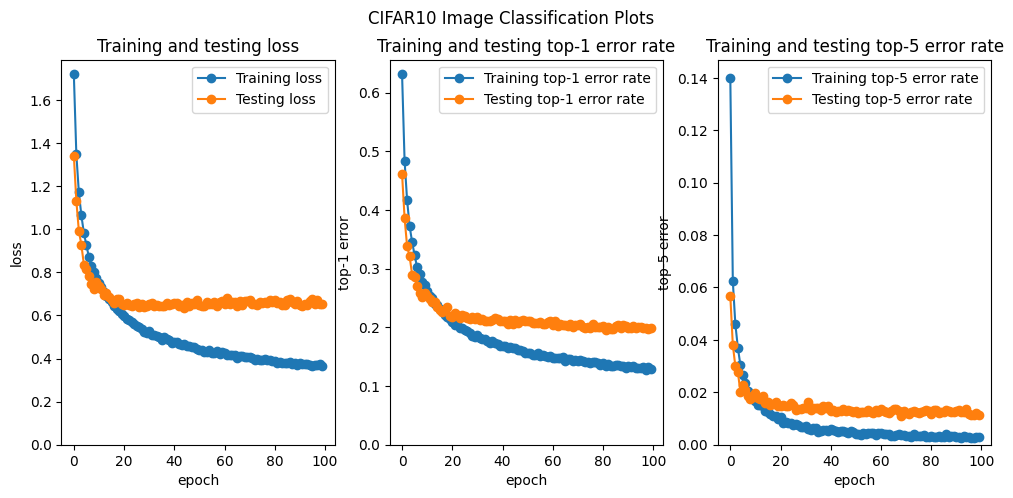

In [ ]:
### Getting error rate metrics
top1_train_error = [1 - x for x in history_p2_1.history['accuracy']]
top5_train_error = [1 - x for x in history_p2_1.history['top_5_accuracy']]
top1_test_error = [1 - x for x in history_p2_1.history['val_accuracy']]
top5_test_error = [1 - x for x in history_p2_1.history['val_top_5_accuracy']]

### Plotting
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# training and testing loss
ax1.plot(history_p2_1.history['loss'],'-o', label='Training loss')
ax1.plot(history_p2_1.history['val_loss'],'-o', label='Testing loss')
ax1.set_ylim(ymin=0)
ax1.set_title('Training and testing loss')
ax1.set_ylabel('loss')
ax1.set_xlabel('epoch')
ax1.legend(loc='upper right')

# training and testing error-1 rate
ax2.plot(top1_train_error,'-o', label='Training top-1 error rate')
ax2.plot(top1_test_error,'-o', label='Testing top-1 error rate')
ax2.set_ylim(ymin=0)
ax2.set_title('Training and testing top-1 error rate')
ax2.set_ylabel('top-1 error')
ax2.set_xlabel('epoch')
ax2.legend(loc='upper right')

# training and testing error-5 rate
ax3.plot(top5_train_error,'-o', label='Training top-5 error rate')
ax3.plot(top5_test_error,'-o', label='Testing top-5 error rate')
ax3.set_ylim(ymin=0)
ax3.set_title('Training and testing top-5 error rate')
ax3.set_ylabel('top-5 error')
ax3.set_xlabel('epoch')
ax3.legend(loc='upper right')

f.suptitle('CIFAR10 Image Classification Plots')

#### Baseline Model Results:
- While training loss and error rates continue to decrease across the 100 epochs towards 0, testing loss and both error rates begin to plateau ~20 epochs and slow their decrease, with some minor fluctuation
  - Though the model is more stable than those exhibited in P1, the gap between training and testing indicate overfitting
  - The testing top-5 error rate already starts at a low level for both training (\~14%) and testing data (<\~6%), and it quickly declines, both already reaching 2% by the 10th epoch, while the training top-5 error rate plateaus near 0%
  - The testing top-1 error rate similarly declines quickly in the first several epochs until it plateaus while the training steadily declines
- The training loss continues to decrease while the testing loss stabilizes with some fluctuation, so though the training model is still learning about the training data, by the ~22nd epoch, it starts to memorize noise from the training data rather than being able to generalize more about classifying other images

At the 100th epoch, the following are the training and testing metrics:

| Dataset      | Loss   | Top-1 Error Rate | Top-5 Error Rate |
| ------------ | ------ | ---------------- | ---------------- |
| **Training** | 0.3611 | 12.86%       | 0.30%        |
| **Testing**  | 0.6522 | 19.85%       | 1.15%        |

Thus, the test accuracy is decent (**\~80.15%**), but it can be improved while also addressing the overfitting issue with modifications to the model.

### Model \# 2:

The following model is an improvement to the "baseline" convolution neural network by incorporating:
- *Data augmentation layers* (`RandomFlip`, `RandomTranslation`) at the beginning to improve generalization by slightly adjusting the images so that the model doesn't just train on the static data, thus helping reduce the overfitting from the baseline
- *Batch normalization for each convolution block* and after the fully connected layer to help prevent the vanishing gradient and enable weights to continue adjusting over iterations and balance the effects of `Dropout`
- Using a *learning rate scheduler (`ReduceLROnPlateau`)* when fitting the model to dynamically adjust the learning rate while training when it stops improving, and it helps counteract instability from the data augmentations mentioned above
- Included *`EarlyStopping`* to save computational efficiency and prevent excessive overfitting at later epochs

In [ ]:
### Build model
def build_compile_p2_model2():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(Flatten())
    model.add(Dense(256, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    model.compile(optimizer='adam',
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model

In [ ]:
### Build/Compile model using function above
model_p2_2 = build_compile_p2_model2()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_7            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 622,282 (2.37 MB)

 Trainable params: 621,322 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

#### Training the model:

In this version, I use the learning scheduler `ReduceLROnPlateau` to adjust the learning rate periodically, as well as use `EarlyStopping` to for computational efficiency and to prevent overfitting towards the later epochs.

In [ ]:
### Using ReduceLROnPlateau as adaptive learning rate
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

### Early stopping
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

### Train model, track time to train
start = time.time()

history_p2_2 = model_p2_2.fit(train_data, callbacks=[reduce_lr, es], validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.3289 - loss: 2.2095 - top_5_accuracy: 0.8240 - val_accuracy: 0.2586 - val_loss: 2.4520 - val_top_5_accuracy: 0.8301 - learning_rate: 0.0010
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5072 - loss: 1.3752 - top_5_accuracy: 0.9349 - val_accuracy: 0.5679 - val_loss: 1.2263 - val_top_5_accuracy: 0.9493 - learning_rate: 0.0010
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5739 - loss: 1.1782 - top_5_accuracy: 0.9555 - val_accuracy: 0.6185 - val_loss: 1.0802 - val_top_5_accuracy: 0.9656 - learning_rate: 0.0010
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6158 - loss: 1.0784 - top_5_accuracy: 0.9628 - val_accuracy: 0.6780 - val_loss: 0.9082 - val_top_5_accuracy: 0.9769 - learning_rate: 0.0010
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6379 - loss: 1.0156 - top_5_accuracy: 0.9676 - val_accuracy: 0.7106 - val_loss: 0.8285 - val_top_5_

#### Visualizing average loss, top-1 error rate, and top-5 error rate:

Text(0.5, 0.98, 'CIFAR10 Image Classification Plots')

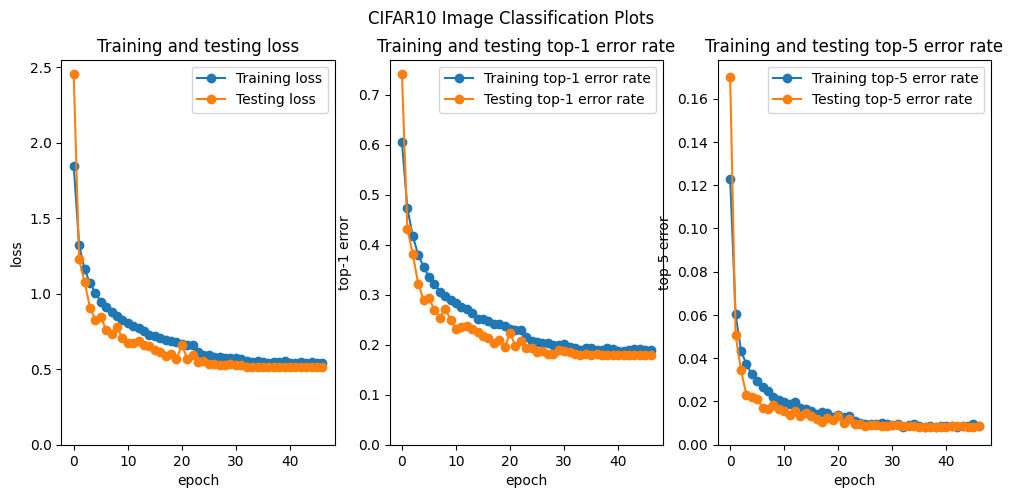

In [ ]:
### Getting error rate metrics
top1_train_error = [1 - x for x in history_p2_2.history['accuracy']]
top5_train_error = [1 - x for x in history_p2_2.history['top_5_accuracy']]
top1_test_error = [1 - x for x in history_p2_2.history['val_accuracy']]
top5_test_error = [1 - x for x in history_p2_2.history['val_top_5_accuracy']]

### Plotting
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# training and testing loss
ax1.plot(history_p2_2.history['loss'],'-o', label='Training loss')
ax1.plot(history_p2_2.history['val_loss'],'-o', label='Testing loss')
ax1.set_ylim(ymin=0)
ax1.set_title('Training and testing loss')
ax1.set_ylabel('loss')
ax1.set_xlabel('epoch')
ax1.legend(loc='upper right')

# training and testing error-1 rate
ax2.plot(top1_train_error,'-o', label='Training top-1 error rate')
ax2.plot(top1_test_error,'-o', label='Testing top-1 error rate')
ax2.set_ylim(ymin=0)
ax2.set_title('Training and testing top-1 error rate')
ax2.set_ylabel('top-1 error')
ax2.set_xlabel('epoch')
ax2.legend(loc='upper right')

# training and testing error-5 rate
ax3.plot(top5_train_error,'-o', label='Training top-5 error rate')
ax3.plot(top5_test_error,'-o', label='Testing top-5 error rate')
ax3.set_ylim(ymin=0)
ax3.set_title('Training and testing top-5 error rate')
ax3.set_ylabel('top-5 error')
ax3.set_xlabel('epoch')
ax3.legend(loc='upper right')

f.suptitle('CIFAR10 Image Classification Plots')

#### Model \#2 Results:

Model changes:

- The effects of the batch normalization layers can be see in that the losses, top-1 error rates, and top-5 error rates converge a bit slower than in the baseline model, not reaching plateau until ~30 epochs
- The overfitting issue seen in the baseline model is addressed, as the training and testing metrices are much more aligned
- The plots converge more smoothly and with fewer fluctuations, only seeing a slight jump in decreasing when the learning rate was scaled down
- With early stopping, the training stopped after the 47th epoch, in which the learning rate was very low at 1.0000e-06

Loss, Error-1 Rate, and Error-5 Rate changes:

- Although the training loss, error-1 rate, and error-5 rate are all higher than those in the baseline model, its performance much more closely mirrors that of the testing data, which makes it a more accurate model
- Testing loss, error-1 rate, and error-5 rate all decreased compared to the baseline model

| Dataset      | Loss   | Top-1 Error Rate | Top-5 Error Rate |
| ------------ | ------ | ---------------- | ---------------- |
| **Training** | 0.5457 | 18.91%       | 0.85%        |
| **Testing**  | 0.5140 | 17.98%       | 0.85%        |

Thus, the test accuracy marginally improves (from \~80.15% to **\~82.02%**), all while addressing the overfitting issue from before and maintaining stability.

### Model \# 3:
The following model is an improvement to model #2 above with the following modifications:
- *Removing `Dropout` layers from the first 2 convolution blocks* to only focus on the layers containing most of the parameters that are prone to overfitting
- *Adding an additional convolution block* to go deeper by increasing non-linearity and capturing more complex features to improve accuracy
- Incorporating *L2 regularization* to the convolution layers to temper overfitting due to increasing the complexity of the model
- Using *`GlobalAveragePooling2D`* instead of `Flatten` prior to the fully connected Dense layer since `Flatten` retains the large number of parameters, whereas `GlobalAveragePooling2D` significantly reduces the increased number of parameters from the convolution block and helps generalize before the fully connected layer while still converting it to a 1D vector
- Applying an *exponential decay learning rate with the Adam optimizer rather than the `ReduceLROnPlateau`* learning scheduler used in P2 to have a smoother learning rate decay rather than sharper drops seen in P2

In [11]:
### Build model
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.001, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model


In [12]:
### Build/Compile model using function above
model_p2_3 = build_compile_p2_model3()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_1            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 529,098 (2.02 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

#### Training the model:

In this version, I removed the learning scheduler `ReduceLROnPlateau` since I applied exponential decay when compiling the model using Adam optimizer, but I continued to use `EarlyStopping` with the same parameters.

In [13]:
### Early stopping
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

### Train model, track time to train
start = time.time()

history_p2_3 = model_p2_3.fit(train_data, callbacks=[es], validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

### Save the all parts of the model to be used in P3
p2_model3_filename = f'{folder_path_p2_best}/p2_bestmodel.h5'
model_p2_3.save(p2_model3_filename)

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3569 - loss: 1.9804 - top_5_accuracy: 0.8535 - val_accuracy: 0.4304 - val_loss: 1.5779 - val_top_5_accuracy: 0.9334
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5456 - loss: 1.3048 - top_5_accuracy: 0.9479 - val_accuracy: 0.6426 - val_loss: 1.0519 - val_top_5_accuracy: 0.9616
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6223 - loss: 1.1025 - top_5_accuracy: 0.9615 - val_accuracy: 0.6681 - val_loss: 0.9869 - val_top_5_accuracy: 0.9741
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6675 - loss: 0.9841 - top_5_accuracy: 0.9728 - val_accuracy: 0.7059 - val_loss: 0.8853 - val_top_5_accuracy: 0.9781
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7025 - loss: 0.8978 - top_5_accuracy: 0.9773 - val_accuracy: 0.7300 - val_loss: 0.8054 - val_top_5_accuracy: 0.9819
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7206 - los

minutes to run:  6.37475715080897


#### Visualizing average loss, top-1 error rate, and top-5 error rate:

Text(0.5, 0.98, 'CIFAR10 Image Classification Plots')

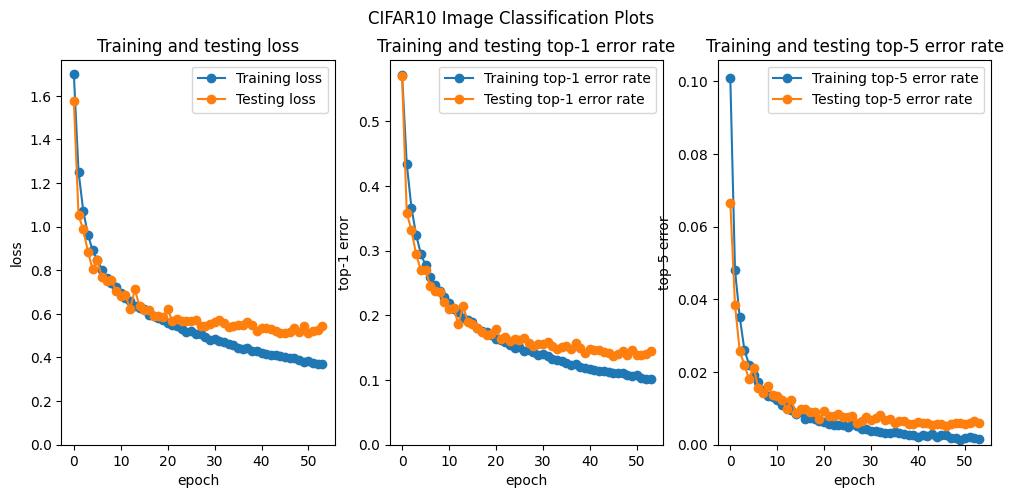

In [14]:
### Getting error rate metrics
top1_train_error = [1 - x for x in history_p2_3.history['accuracy']]
top5_train_error = [1 - x for x in history_p2_3.history['top_5_accuracy']]
top1_test_error = [1 - x for x in history_p2_3.history['val_accuracy']]
top5_test_error = [1 - x for x in history_p2_3.history['val_top_5_accuracy']]

### Plotting
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

# training and testing loss
ax1.plot(history_p2_3.history['loss'],'-o', label='Training loss')
ax1.plot(history_p2_3.history['val_loss'],'-o', label='Testing loss')
ax1.set_ylim(ymin=0)
ax1.set_title('Training and testing loss')
ax1.set_ylabel('loss')
ax1.set_xlabel('epoch')
ax1.legend(loc='upper right')

# training and testing error-1 rate
ax2.plot(top1_train_error,'-o', label='Training top-1 error rate')
ax2.plot(top1_test_error,'-o', label='Testing top-1 error rate')
ax2.set_ylim(ymin=0)
ax2.set_title('Training and testing top-1 error rate')
ax2.set_ylabel('top-1 error')
ax2.set_xlabel('epoch')
ax2.legend(loc='upper right')

# training and testing error-5 rate
ax3.plot(top5_train_error,'-o', label='Training top-5 error rate')
ax3.plot(top5_test_error,'-o', label='Testing top-5 error rate')
ax3.set_ylim(ymin=0)
ax3.set_title('Training and testing top-5 error rate')
ax3.set_ylabel('top-5 error')
ax3.set_xlabel('epoch')
ax3.legend(loc='upper right')

f.suptitle('CIFAR10 Image Classification Plots')

#### Model \#3 Results:

Model changes:

- With the changes to the model above, the convergence is slower and smoother, as can be see in plots for the losses, top-1 error rates, and top-5 error rates, and early stopping ending the training at 63 epochs (as opposed to 47 epochs when `patience=8`)
- There is some minor overfitting, as the testing loss and error rates plateau sooner than those of the training, which continues to decline, but it is not as severe as in the baseline model

Loss, Error-1 Rate, and Error-5 Rate changes:

- Across the board, the training metrics reduced signficantly (loss: 0.5457 to 0.3656 | top-1 error rate: 18.91% to 9.97% | top-5 error rate: 0.85% to 0.15%)
- The testing loss marginally increased (0.5140 to 0.5426) but still remains low, while there is a \~3.5% improvement in the top-1 error rate (17.98% to 14.41%) and a small improvement in the top-5 error rate (0.85% to 0.61%)
- Whereas in P2 the testing data ended up performing better than the training data, this model sees the opposite, which is to be expected


| Dataset      | Loss   | Top-1 Error Rate | Top-5 Error Rate |
| ------------ | ------ | ---------------- | ---------------- |
| **Training** | 0.3656 | 9.97%       | 0.15%        |
| **Testing**  | 0.5426 | 14.41%       | 0.61%        |


Thus, the test accuracy jumps from \~82.02% to **\~85.59%**, though at the expense of some overfitting. However, the loss and top-5 error rate still remain low.

### Overall results interpretation and model comparison:



**Overall Loss and Error Rate Results:**

| Model      | Train Loss   | Test Loss   | Train Top-1 Error Rate | Test Top-1 Error Rate | Train Top-5 Error Rate | Train Top-5 Error Rate |
| ------------ | ------ | ------ | ---------------- | ---------------- | ---------------- |---------------- |
| **Baseline** | 0.3611 |0.6522 | 12.86%       | 19.85%       | 0.30%        | 1.15%        |
| **Model 2 (augment over Baseline)**  | 0.5427 | 0.5140 | 18.91%       | 17.98%       | 0.85%        | 0.85%        |
| **Model 3 (final model)**  | 0.3656 | 0.5426 | 9.97%       | 14.41%       | 0.15%        | 0.61%        |

*Note that I took the metrics from the latest epoch from the training for comparison consistency, even though there may be slightly better figures from earlier epochs, though only marginally.*

- *Baseline:* The gap between the training and testing loss and errors illustrate overfitting, as the model is unable to generalize well, and while training top-1 error keeps improving, it plateaus for testing. However, as a baseline model, it begins at a decent test accuracy \~80%. Its top-5 error rate is the highest among the three models, but at 1.15%, it already almost always correctly classifies the top 5 predictions.

- *Model 2:* With the adjustments mentioned above, model 2 eliminates the overfitting issue, though at the expense of training accuracy since the regularization effectively made the training performance slightly worse than the testing performance. The top-5 error rates are essentially identical though, so the model generalizes well to the test data. The convergence was slower but by the end, the aggressive learning rate scheduler also led to the learning rate being 1e-6.

- *Model 3:* This model performed the best in balancing between reducing overfitting and improving accuracy. The training and testing curves for the loss and error rates are closer than in the baseline, and accuracy improved (i.e., error rates decreased) for both top-1 and top-5 over the two previous models.

**Model Changes:**

The incremental changes from the baseline to Model 2 to Model 3 were made to ensure that stability and a smooth convergence are maintained, while addressing overfitting issues and increasing test accuracy.

- Incorporating the learning scheduler in Model 2 made the learning process more dynamic, and switching to ExponentialDecay in the optimizer removed the jumps to the weights and smoothed out the curves. It also enables balancing exploring loss earlier on in the model with fine-tuning the weights later on.

- Switching from a flatten layer to global average pooling layer helped address the increased number of parameters in Model 3, thus smoothing the loss curve while preventing parameter explosion that can cause overfitting.

- Including Early Stopping in Models 2 and 3 also helped computational efficiency and illustrate how convergence slowed over each model progression.

- Adding a 4th convolution block in Model 3 enabled the model to learn more complex features to distinguish among the images better, and adjustments like regularization and the changes mentioned above helped balance the increased number of parameters and potential overfitting.

**General reflections:**

The goal of the three models was to gradually improve performance, not only to achieve a high test accuracy (and decrease loss and error rates), but also to maintain a stable model that can generalize to other datasets/images. It achieved a test accuracy of 85.59% in the final model. Though ResNet and other CNN architectures are able to achieve >90% accuracy (and >95% top-5 accuracy), Model 3 is still able to achieve a decent result and incrementally improve over the other two to get the best outcome. In addition, throughout all three models, top-5 error rate for training and testing were very low, so the model almost always correctly classifies the top 5 classes.

# **P3. Adversarial robustness**

As explained in the lecture notes, neural networks are vulnerable to imperceptible perturbations of their inputs. This part of the assignment asks you to evaluate and improve the robustness of convolutional networks on CIFAR-10. Custom evaluation and training loops for you to modify, along with a PGD attack implementation and a relative example call, are provided in the assessment1 notebook.

**Task:**
- Given the provided PGD attack implementation, evaluate the robustness of the network from P2 to adversarial attacks by suitably modifying the provided custom evaluation code custom_eval. In particular, evaluate its test adversarial accuracy: the share of test points for which the network correctly classifies under adversarial attacks (when an attack is deployed to imperceptibly perturb each point).
- Vary the perturbation radius eps and the attack parameters (step_size, n_steps) and investigate how this affects model robustness. Can you drive adversarial accuracy to near 0?
- Alter the hyper-parameters of standard training and the architecture: do these affect adversarial robustness?
- Modify the training process to build a network that is more robust to the attacks. You will need to edit the provided custom training code custom_train. Discuss your reasoning and the results. Reduce the number of epochs to reduce training time if necessary.

---

**Hints:**
- Your goal at evaluation is to use the attack to consistently induce misclassifications for a reasonable threat model (typically, eps=8/255, and eps<=16/255, ensuring imperceptibility).
- Your goal when training is to produce a network that is significantly more robust to these attacks. What knowledge could you exploit?

Custom evaluation loop, to edit

### Loading the P2 model

This will be fed into the `cust_eval()` model.

In [ ]:
### Retrieve the model details from the best model in P2 (Model 3)
model_p2_best = load_model(f'{folder_path_p2_best}/p2_bestmodel.h5')

In [ ]:
### Checking that the loaded model works and can be evaluated (using val_data since it wasn't used in P2)
model_p2_best.evaluate(val_data)

79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8633 - loss: 0.5036 - top_5_accuracy: 0.9940


[0.500143826007843, 0.8654000163078308, 0.9940000176429749]

Adversarial attack (PGD): given an input point and an l-infinity perturbation radius, return the approximate worst-case within the possible perturbations according to the loss function

In [ ]:
def pgd_attack(loss_function, model, input, eps, data_std, data_min, data_max,
               n_steps=8, step_size=0.25, training=False):
    # apply normalised epsilon to the input data, making sure we're never crossing the data boundaries
    norm_eps = tf.reshape(eps / data_std, (1, 1, 1, -1))
    input_lb = tf.maximum(input - norm_eps, data_min)
    input_ub = tf.minimum(input + norm_eps, data_max)

    # PGD starts from a random initialiser
    step_size_scaling = (input_ub - input_lb) / 2
    adv_input = tf.Variable(tf.random.uniform(input_lb.shape) * (input_ub - input_lb) + input_lb)

    attack_point = input_lb
    attack_loss = (-np.inf) * tf.ones(input_lb.shape[0], dtype=tf.dtypes.float32)

    # attack loop
    for i in range(n_steps):
        with tf.GradientTape() as gtape:
            adv_outs = model(adv_input, training=training)
            obj = loss_function(adv_outs)
            obj_sum = tf.math.reduce_sum(obj)
        grad = gtape.gradient(obj_sum, adv_input)

        # keep the best attack point so far
        attack_point = tf.where(
            tf.reshape((obj >= attack_loss), (-1,) + (1,) * (int(tf.rank(input_lb) - 1))), x=adv_input, y=attack_point)
        attack_loss = tf.where(obj >= attack_loss, x=obj, y=attack_loss)

        adv_input = adv_input + step_size * step_size_scaling * tf.sign(grad)
        adv_input = tf.Variable(tf.maximum(tf.minimum(adv_input, input_ub), input_lb))

    adv_outs = model(adv_input, training=training)
    obj = loss_function(adv_outs)
    attack_point = tf.where(tf.reshape((obj >= attack_loss), (-1,) + (1,) * (int(tf.rank(input_lb) - 1))),
                            x=adv_input, y=attack_point)

    return attack_point

#### `cust_eval()` and model robustness analysis:

The code above applies different eps values, which varies the level of threat applied. When eps=0, it means that `pgd_attack()` isn't used, and we validate that the `cust_eval()` function does evaluate the model appropriately because its accuracy is 86.25%, which is near the test accuracy achieved in P2 by that model (85.59%).

Already when `eps=2/255`, the test adversarial accuracy is significantl yreduced to 11.46%. This means that even with a lower eps level, the adversarial attack is able to perturb the images enough to cause significant misclassification.

By the time `eps=4/255`, the test adversarial accuracy is effectively driven to 0%. This indicates that my P2 model (Model 3) is not robust towards adversarial attacks and is at significant risk, despite being able to achieve a high accuracy.

### Evaluating the adversarial robustness: `cust_eval()`

The code below has been modified to evaluate a neural network model but apply the adversarial attack (`pgd_attack()` function).

The loss function used is `SparseCategoricalCrossentropy` in which `reduction='none'`. This means that the loss values are aggregated across the batch, which enables the adversarial attack to get individual loss values and perturb the pixels, rather than the weights, for those that have lower loss, as seen in the `pgd_attack()` function above, and be more likely to be misclassified.

In [ ]:
# Customized cust_eval() function

def custom_eval(eval_dataset, input_model, n_eps=8/255, num_steps=10, step_sz=0.25):
    val_acc_metric = keras.metrics.SparseCategoricalAccuracy()

    # Directly inputting the mean and std from the data loader function
    mean=tf.constant([0.4914, 0.4822, 0.4465])
    std=tf.constant([0.2023, 0.1994, 0.2010])

    data_std = tf.reshape(std, (1, 1, 1, -1))
    data_min = tf.reshape((0. - mean) / std, (1, 1, 1, -1))
    data_max = tf.reshape((1. - mean) / std, (1, 1, 1, -1))

    for x, y in eval_dataset:

      # Loss function for attack, with the goal to maximize it
      loss_fun = keras.losses.SparseCategoricalCrossentropy(reduction='none')
      loss_att = functools.partial(loss_fun, y)

      # Create adversarial examples for the batch
      x_adversarial = pgd_attack( # modify the example
                                 loss_function=loss_att,
                                 model=input_model,
                                 input=x,
                                 eps=n_eps,
                                 data_std=data_std,
                                 data_min=data_min,
                                 data_max=data_max,
                                 n_steps=num_steps,
                                 step_size=step_sz
                                 )

      # Evaluate the model on the adversarial images
      val_logits = input_model(x_adversarial, training=False)
      # Update val metrics
      val_acc_metric.update_state(y, val_logits)

    val_acc = val_acc_metric.result()
    val_acc_metric.reset_state()
    print(f"Eval acc with (eps={round(n_eps,4)}, n_steps={num_steps}, step_size={step_sz}): {float(val_acc):.4f}")
    return val_acc

In [ ]:
### Run the custom_eval() function to test the robustness of Model 3 from P2 (i.e., test adversarial accuracy)
  # Note: The inclusion of eps=0.0 is to ensure that the cust_eval() function runs properly,
  # as it should output the expected accuracy without the pgd_attack()

for eps_level in [0/255, 1/255, 2/255, 3/255, 4/255, 8/255, 16/255]:
  start = time.time()

  custom_eval(test_data, model_p2_best, n_eps=eps_level, num_steps=10, step_sz=0.25)

  end = time.time()
  time_nn = (end-start) / 60
  print('minutes to run: ', round(time_nn,4))

Eval acc with (eps=0.0, n_steps=10, step_size=0.25): 0.8625
minutes to run:  0.7624
Eval acc with (eps=0.0039, n_steps=10, step_size=0.25): 0.4034
minutes to run:  0.7954
Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.1141
minutes to run:  0.733
Eval acc with (eps=0.0118, n_steps=10, step_size=0.25): 0.0207
minutes to run:  0.6919
Eval acc with (eps=0.0157, n_steps=10, step_size=0.25): 0.0025
minutes to run:  0.766
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.0000
minutes to run:  0.6129
Eval acc with (eps=0.0627, n_steps=10, step_size=0.25): 0.0000
minutes to run:  0.6732


### Adjusting the attack parameters:

Given the level of robustness of the P2 model is low, as seen by the low perturbation radius `eps` needed to already drive the accuracy to 0%, I'll keep it constant at `eps=2/255` and adjust `step_size` and `n_steps` individually to investigate how it affects the model robustness.

In [ ]:
### Adjusting n_steps:

for steps in [2,4,6,8,10,12,14,16,18,20,25,30,40]:
  start = time.time()

  custom_eval(test_data, model_p2_best, n_eps=2/255, num_steps=steps, step_sz=0.25)

  end = time.time()
  time_nn = (end-start) / 60
  print('minutes to run: ', round(time_nn,4))

Eval acc with (eps=0.0078, n_steps=2, step_size=0.25): 0.5063
minutes to run:  0.1801
Eval acc with (eps=0.0078, n_steps=4, step_size=0.25): 0.2720
minutes to run:  0.2791
Eval acc with (eps=0.0078, n_steps=6, step_size=0.25): 0.1649
minutes to run:  0.3924
Eval acc with (eps=0.0078, n_steps=8, step_size=0.25): 0.1290
minutes to run:  0.4967
Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.1145
minutes to run:  0.6167
Eval acc with (eps=0.0078, n_steps=12, step_size=0.25): 0.1046
minutes to run:  0.7146
Eval acc with (eps=0.0078, n_steps=14, step_size=0.25): 0.1005
minutes to run:  0.8301
Eval acc with (eps=0.0078, n_steps=16, step_size=0.25): 0.0975
minutes to run:  0.9365
Eval acc with (eps=0.0078, n_steps=18, step_size=0.25): 0.0960
minutes to run:  1.0421
Eval acc with (eps=0.0078, n_steps=20, step_size=0.25): 0.0940
minutes to run:  1.1642
Eval acc with (eps=0.0078, n_steps=25, step_size=0.25): 0.0920
minutes to run:  1.421
Eval acc with (eps=0.0078, n_steps=30, step_size

In [ ]:
### Adjusting step_size:

for size in [0.05,0.1,0.15,0.2,0.25,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0,1.5,2.0]:
  start = time.time()

  custom_eval(test_data, model_p2_best, n_eps=2/255, num_steps=10, step_sz=size)

  end = time.time()
  time_nn = (end-start) / 60
  print('minutes to run: ', round(time_nn,4))

Eval acc with (eps=0.0078, n_steps=10, step_size=0.05): 0.4776
minutes to run:  0.6105
Eval acc with (eps=0.0078, n_steps=10, step_size=0.1): 0.2515
minutes to run:  0.6056
Eval acc with (eps=0.0078, n_steps=10, step_size=0.15): 0.1578
minutes to run:  0.6093
Eval acc with (eps=0.0078, n_steps=10, step_size=0.2): 0.1243
minutes to run:  0.6183
Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.1147
minutes to run:  0.6117
Eval acc with (eps=0.0078, n_steps=10, step_size=0.3): 0.1080
minutes to run:  0.5918
Eval acc with (eps=0.0078, n_steps=10, step_size=0.4): 0.1048
minutes to run:  0.6093
Eval acc with (eps=0.0078, n_steps=10, step_size=0.5): 0.1072
minutes to run:  0.6111
Eval acc with (eps=0.0078, n_steps=10, step_size=0.6): 0.1106
minutes to run:  0.5998
Eval acc with (eps=0.0078, n_steps=10, step_size=0.7): 0.1150
minutes to run:  0.6056
Eval acc with (eps=0.0078, n_steps=10, step_size=0.8): 0.1197
minutes to run:  0.6081
Eval acc with (eps=0.0078, n_steps=10, step_size=0.

#### Attack parameter analysis:

When increasing each of the three attack parameters `eps`, `step_size`, and `n_steps`, the P2 model weakens, as the higher they are, the higher the test adversarial accuracy decreases.

However, as seen above, though there is a steeper drop in accuracy in the initial increments, each of these have a reduced effect as it continues to increase, though to varying degrees.

- 'eps': This has the strongest effect in weakening the model, due to its direct effect of the degree to which an image can be perturbed. This can be seen by the test adversarial accuracy sharply declining immediately, even among small increments. As mentioned above, by `eps=4/255`, the accuracy is driven to 0%.

- `n_steps`: Going from 2 to 4 decreases accuracy by 23.41%, but going from 14 to 16 only decreases accuracy by 0.29%. It It begins to plateau, however, after 10, and the effect is decreased. Note that with more steps, it takes longer to evaluate the model, which indicates that there is a balance with computational efficiency that the adversarial attack needs to account for.

- `step_size`: It initially declines sharply (i.e., going from 0.05 to 0.1 decreases accuracy by 22.61%), but it eventually plateaus and then even begins to slowly increase again, starting after `step_size=0.4`. After taking too 'large' of steps, the adverse attack's ability to perturb the images weakens.

### Altering the hyper-parameters of standard training and architecture:

The following alterations to hyper-parameters of the standard training and architecture were applied:

- More `Dropout` (specifically in Conv. blocks 1 and 2
- Increased L2 regularization/weight decay (0.001 instead of 0.0001)
- Adjusting the learning rate (from starting at 0.001 to starting at 0.0001)

#### Model 3 from P2:

In [ ]:
### Original Model 3 from P2
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.001, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model


#### Hyper-parameter adjustment: More Dropout

Adding the dropout layers to convolution blocks #1 and #2

In [ ]:
### More dropout
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.001, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model


### Build/Compile model
model_p2_best_moredrop = build_compile_p2_model3()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_2            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 529,098 (2.02 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
### Early stopping
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

### Train model, track time to train
start = time.time()

history_p2_3 = model_p2_best_moredrop.fit(train_data, callbacks=[es], validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

### Save the weights after training for more dropout
weights_filename = f'{folder_path_p2_best}/p3_moredrop.weights.h5'
model_p2_best_moredrop.save_weights(weights_filename)
print(f'Saved weights to {weights_filename}')

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.3227 - loss: 2.0897 - top_5_accuracy: 0.8267 - val_accuracy: 0.2381 - val_loss: 3.0704 - val_top_5_accuracy: 0.7526
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.4864 - loss: 1.4736 - top_5_accuracy: 0.9305 - val_accuracy: 0.4979 - val_loss: 1.6522 - val_top_5_accuracy: 0.9451
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5676 - loss: 1.2531 - top_5_accuracy: 0.9529 - val_accuracy: 0.5873 - val_loss: 1.2367 - val_top_5_accuracy: 0.9613
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6142 - loss: 1.1288 - top_5_accuracy: 0.9634 - val_accuracy: 0.6540 - val_loss: 1.0350 - val_top_5_accuracy: 0.9690
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6513 - loss: 1.0374 - top_5_accuracy: 0.9701 - val_accuracy: 0.6794 - val_loss: 0.9853 - val_top_5_accuracy: 0.9722
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6738 - los

In [ ]:
more_drop = custom_eval(test_data, model_p2_best_moredrop, n_eps=2/255, num_steps=10, step_sz=0.25)

Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.2047


#### Hyper-parameter adjustment: Less Dropout

Removing the dropout layers from convolution block #3

In [ ]:
### More dropout
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.001, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model


### Build/Compile model
model_p2_best_lessdrop = build_compile_p2_model3()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_6 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_6            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,098 (2.02 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
### Early stopping
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

### Train model, track time to train
start = time.time()

history_p2_3 = model_p2_best_lessdrop.fit(train_data, callbacks=[es], validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

### Save the weights after training for more dropout
weights_filename = f'{folder_path_p2_best}/p3_lessdrop.weights.h5'
model_p2_best_lessdrop.save_weights(weights_filename)
print(f'Saved weights to {weights_filename}')

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.3700 - loss: 1.9393 - top_5_accuracy: 0.8612 - val_accuracy: 0.4435 - val_loss: 1.6088 - val_top_5_accuracy: 0.9203
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.5704 - loss: 1.2579 - top_5_accuracy: 0.9498 - val_accuracy: 0.6383 - val_loss: 1.0733 - val_top_5_accuracy: 0.9646
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6463 - loss: 1.0480 - top_5_accuracy: 0.9677 - val_accuracy: 0.6605 - val_loss: 1.0244 - val_top_5_accuracy: 0.9702
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6901 - loss: 0.9292 - top_5_accuracy: 0.9767 - val_accuracy: 0.7040 - val_loss: 0.9189 - val_top_5_accuracy: 0.9715
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7254 - loss: 0.8355 - top_5_accuracy: 0.9795 - val_accuracy: 0.7084 - val_loss: 0.9196 - val_top_5_accuracy: 0.9767
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7380 - loss

In [ ]:
less_drop = custom_eval(test_data, model_p2_best_lessdrop, n_eps=2/255, num_steps=10, step_sz=0.25)

Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.0769


#### Hyper-parameter adjustment: Increased L2 Regularization

Raise L2 regularization from 0.0001 to 0.001

In [ ]:
### Increased L2 regularization (from 0.0001 to 0.001)
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.001, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model


### Build/Compile model
model_p2_3_morel2 = build_compile_p2_model3()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_3            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 529,098 (2.02 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
### Early stopping
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

### Train model, track time to train
start = time.time()

history_p2_3 = model_p2_3_morel2.fit(train_data, callbacks=[es], validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

### Save the weights after training for more L2 regularization
weights_filename = f'{folder_path_p2_best}/p3_morel2.weights.h5'
model_p2_3_morel2.save_weights(weights_filename)
print(f'Saved weights to {weights_filename}')

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - accuracy: 0.8529 - loss: 0.6309 - top_5_accuracy: 0.9952 - val_accuracy: 0.8337 - val_loss: 0.7043 - val_top_5_accuracy: 0.9909
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - accuracy: 0.8545 - loss: 0.6254 - top_5_accuracy: 0.9953 - val_accuracy: 0.8398 - val_loss: 0.6835 - val_top_5_accuracy: 0.9925
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8548 - loss: 0.6179 - top_5_accuracy: 0.9955 - val_accuracy: 0.8361 - val_loss: 0.6939 - val_top_5_accuracy: 0.9932
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8594 - loss: 0.6047 - top_5_accuracy: 0.9960 - val_accuracy: 0.8391 - val_loss: 0.6797 - val_top_5_accuracy: 0.9923
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8592 - loss: 0.6037 - top_5_accuracy: 0.9952 - val_accuracy: 0.8497 - val_loss: 0.6504 - val_top_5_accuracy: 0.9922
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8659 - los

In [ ]:
more_l2reg = custom_eval(test_data, model_p2_3_morel2, n_eps=2/255, num_steps=10, step_sz=0.25)

Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.0745


#### Hyper-parameter adjustment: Decreased L2 Regularization

Lower L2 regularization from 0.0001 to 0.00001

In [ ]:
### Increased L2 regularization (from 0.0001 to 0.001)
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.00001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.00001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.00001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.00001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.001, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model


### Build/Compile model
model_p2_3_lessl2 = build_compile_p2_model3()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_7 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_7            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 529,098 (2.02 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
### Early stopping
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

### Train model, track time to train
start = time.time()

history_p2_3 = model_p2_3_lessl2.fit(train_data, callbacks=[es], validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

### Save the weights after training for more L2 regularization
weights_filename = f'{folder_path_p2_best}/p3_lessl2.weights.h5'
model_p2_3_lessl2.save_weights(weights_filename)
print(f'Saved weights to {weights_filename}')

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3449 - loss: 2.0002 - top_5_accuracy: 0.8451 - val_accuracy: 0.4320 - val_loss: 1.5742 - val_top_5_accuracy: 0.9026
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.5390 - loss: 1.3043 - top_5_accuracy: 0.9423 - val_accuracy: 0.6166 - val_loss: 1.0789 - val_top_5_accuracy: 0.9665
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.6071 - loss: 1.0952 - top_5_accuracy: 0.9621 - val_accuracy: 0.6816 - val_loss: 0.9011 - val_top_5_accuracy: 0.9762
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6555 - loss: 0.9766 - top_5_accuracy: 0.9712 - val_accuracy: 0.7107 - val_loss: 0.8365 - val_top_5_accuracy: 0.9765
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6918 - loss: 0.8754 - top_5_accuracy: 0.9770 - val_accuracy: 0.6936 - val_loss: 0.8974 - val_top_5_accuracy: 0.9726
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7101 - loss

In [ ]:
less_l2reg = custom_eval(test_data, model_p2_3_lessl2, n_eps=2/255, num_steps=10, step_sz=0.25)

Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.1046


#### Hyper-parameter adjustment: Higher learning rate

In [ ]:
### Lowering the learning rate from 0.001 to 0.0001
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.0001, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model


### Build/Compile model
model_p2_3_less_lr = build_compile_p2_model3()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_5            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 529,098 (2.02 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
### Early stopping
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

### Train model, track time to train
start = time.time()

history_p2_3 = model_p2_3_less_lr.fit(train_data, callbacks=[es], validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

### Save the weights after training for smaller learning rate
weights_filename = f'{folder_path_p2_best}/p3_lesslr.weights.h5'
model_p2_3_less_lr.save_weights(weights_filename)
print(f'Saved weights to {weights_filename}')

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.2651 - loss: 2.3629 - top_5_accuracy: 0.7700 - val_accuracy: 0.3627 - val_loss: 1.8171 - val_top_5_accuracy: 0.8647
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.3957 - loss: 1.7969 - top_5_accuracy: 0.8872 - val_accuracy: 0.5082 - val_loss: 1.3965 - val_top_5_accuracy: 0.9289
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4438 - loss: 1.6246 - top_5_accuracy: 0.9106 - val_accuracy: 0.5360 - val_loss: 1.3355 - val_top_5_accuracy: 0.9370
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4835 - loss: 1.4920 - top_5_accuracy: 0.9271 - val_accuracy: 0.5553 - val_loss: 1.2679 - val_top_5_accuracy: 0.9469
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5119 - loss: 1.4207 - top_5_accuracy: 0.9338 - val_accuracy: 0.5745 - val_loss: 1.2298 - val_top_5_accuracy: 0.9533
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.5325 - los

In [ ]:
less_lr = custom_eval(test_data, model_p2_3_less_lr, n_eps=2/255, num_steps=10, step_sz=0.25)

Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.0355


#### Hyper-parameter adjustment: Lower learning rate

In [ ]:
### Lowering the learning rate from 0.001 to 0.0001
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.01, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model


### Build/Compile model
model_p2_3_more_lr = build_compile_p2_model3()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_8 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation_8            │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_29 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 529,098 (2.02 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 1,984 (7.75 KB)

In [ ]:
### Early stopping
es = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

### Train model, track time to train
start = time.time()

history_p2_3 = model_p2_3_more_lr.fit(train_data, callbacks=[es], validation_data=test_data, epochs=n_epochs)

end = time.time()
time_nn = (end-start) / 60
print('minutes to run: ', time_nn)

### Save the weights after training for smaller learning rate
weights_filename = f'{folder_path_p2_best}/p3_morelr.weights.h5'
model_p2_3_more_lr.save_weights(weights_filename)
print(f'Saved weights to {weights_filename}')

Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.3142 - loss: 2.2669 - top_5_accuracy: 0.8282 - val_accuracy: 0.4776 - val_loss: 1.6014 - val_top_5_accuracy: 0.9253
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5221 - loss: 1.5135 - top_5_accuracy: 0.9424 - val_accuracy: 0.5795 - val_loss: 1.4561 - val_top_5_accuracy: 0.9372
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6088 - loss: 1.3370 - top_5_accuracy: 0.9611 - val_accuracy: 0.5918 - val_loss: 1.5389 - val_top_5_accuracy: 0.9350
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6524 - loss: 1.2833 - top_5_accuracy: 0.9670 - val_accuracy: 0.6397 - val_loss: 1.3262 - val_top_5_accuracy: 0.9720
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.6714 - loss: 1.2584 - top_5_accuracy: 0.9723 - val_accuracy: 0.6502 - val_loss: 1.3206 - val_top_5_accuracy: 0.9706
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6813 - loss

In [ ]:
less_lr = custom_eval(test_data, model_p2_3_more_lr, n_eps=2/255, num_steps=10, step_sz=0.25)

Eval acc with (eps=0.0078, n_steps=10, step_size=0.25): 0.2086


#### Comparing the results of the hyper-parameter adjustments:

The table below shows the test adversarial accuracies with the following attack parameters: `n_eps=2/255`, `num_steps=10`, `step_sz=0.25`

Test adversarial accuracies:
| Model Variation             | Test Adversarial Accuracy (%) |
| --------------------------- | -------------------- |
| Original P2 Model (Model 3) | 11.41%               |
| More Dropout                | 20.47%               |
| Less Dropout                | 7.69%                |
| More L2 Regularization      | 7.45%                |
| Less L2 Regularization      | 10.46%               |
| Higher Learning Rate        | 3.55%                |
| Lower Learning Rate         | 20.86%               |

In addition, the table below shows the test accuracies by the last epoch from when each model is originally trained:

Test accuracies (by the last epoch):
| Model Variation             | Test Accuracy (%) |
| --------------------------- | ------------ |
| Original P2 Model (Model 3) | 85.59%       |
| More Dropout                | 85.43%       |
| Less Dropout                | 85.60%       |
| More L2 Regularization      | 88.00%       |
| Less L2 Regularization      | 86.15%       |
| Higher Learning Rate        | 77.85%       |
| Lower Learning Rate         | 71.84%       |


The original P2 model's test adversarial accuracy (11.41%) is used as the benchmark for comparison:
- *Dropout*: Note that the regular test accuracies with more and less `Dropout` layers is similar to the original P2 model (\~85.5%). Having more `Dropout` layers improves the robustness of the model, as the accuracy increases by \~9%, but fewer `Dropout` layers indicate the model is weaker.
  - This implies that more `Dropout` layers increases the robustness of the model against adversarial attacks.
- *L2 Regularization*: Changing the L2 regularization (both increasing and decreasing) actually improved P2 model's performance, although more significantly for the 'More L2 Regularization' variation. However, both are less robust than the original P2 model and have lower test adversarial accuracies.
  - This indicates that there is a 'sweet spot' in which L2 regularization can most effectively make the model more robust, and the original P2 model's L2 regularization level of 0.0001 seems to be better.
- *Learning Rate*: Both increasing and decreasing the learning rate used in the Adam optimizer decreased the test accuracy of the models, but the effects on the test adversarial accuracies are intriguing. Having a higher learning rate sharly decreases the robustness of the model, but decreasing the learning rate significantly improved the robustness of the model. Even though the original test accuracy was much lower (71.84%), it had the highest test adversarial accuracy of all the 7 models (20.86%).
  - There is a balance between adjusting the learning rate to a lower level as to avoid significantly decreasing the original test accuracy, while looking to make the model more robust to adversarial attacks.

### Modifying the training process

The function below is the customized training function that trains the inputted model using examples perturbed by the adversarial attack function `pgd_attack()`.

The main modification to the provided `custom_train()` template is incorporating the chosen loss function and creating the adversarial examples, similar to in the `custom_eval()` function above. In addition, `EarlyStopping` was incorporated to prevent overtraining and save computational efficiency if the evaluation accuracy doesn't improve after a certain number of epochs (i.e., patience).

The rest of the function remains intact, with only minor modifications to the argument names and including `n_eps` as an argument. When the model gets trained using this function, it will continue to iterate over the model and training data to improve its test accuracy and evaluate against the `custom_eval()` function to see how it performs against the adversarial attack.

In [ ]:
# Customized training function

def custom_train(train_dataset, val_dataset, input_model, lr=1e-3, wd=1e-3, epochs=30,
                 val_freq=1, n_eps=8/255, patience=5):

    # Track duration of each training epoch/iteration
    start = time.time()

    loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    optimizer = keras.optimizers.Adam(learning_rate=lr, weight_decay=wd)
    train_acc_metric = keras.metrics.SparseCategoricalAccuracy()

    # Directly inputting the mean and std from the data loader function
    mean=tf.constant([0.4914, 0.4822, 0.4465])
    std=tf.constant([0.2023, 0.1994, 0.2010])

    data_std = tf.reshape(std, (1, 1, 1, -1))
    data_min = tf.reshape((0. - mean) / std, (1, 1, 1, -1))
    data_max = tf.reshape((1. - mean) / std, (1, 1, 1, -1))

    # To track for EarlyStopping
    best_val_acc = 0
    patience_ct = 0
    best_weights = None

    for epoch in range(epochs):

        # Iterate over the batches of a dataset.
        for x, y in train_dataset:

            # Include adversarial attack samples
            # Loss function for attack, with the goal to maximize it
            loss_fun = keras.losses.SparseCategoricalCrossentropy(reduction='none')
            loss_att = functools.partial(loss_fun, y)

            # Create adversarial examples for the batch
            x_adversarial = pgd_attack( # modify the example
                                      loss_function=loss_att,
                                      model=input_model,
                                      input=x,
                                      eps=n_eps,
                                      data_std=data_std,
                                      data_min=data_min,
                                      data_max=data_max,
                                      n_steps=5,
                                      step_size=0.25
                                      )

            # Training on the adversarial examples
            with tf.GradientTape() as tape:
                # Forward pass.
                logits = input_model(x_adversarial)
                # Loss value for this batch.
                loss_value = loss_fn(y, logits)
                # Add extra loss terms to the loss value.
                loss_value += sum(input_model.losses)

            # Update the weights of the model to minimize the loss value.
            gradients = tape.gradient(loss_value, input_model.trainable_weights)
            optimizer.apply_gradients(zip(gradients, input_model.trainable_weights))
            train_acc_metric.update_state(y, logits)

        train_acc = train_acc_metric.result()
        train_acc_metric.reset_state()
        print(f"Train acc (Epoch: {epoch+1} of {epochs}): {float(train_acc):.4f}")

        if (epoch + 1) % val_freq == 0:
            val_acc = custom_eval(val_dataset, input_model) # track current val_acc

        # Incorporate EarlyStopping so that it ends if no improvements are made
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = input_model.get_weights()
            patience_ct = 0
        else: # if not improving, continue running but only up to # patience iterations
            patience_ct += 1
            print(f"No improvement after {patience_ct} epochs")
            if patience_ct >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                input_model.set_weights(best_weights) # put back the best weights seen

                end = time.time()
                time_nn = (end-start) / 60
                print('minutes to run: ', time_nn)
                break

    end = time.time()
    time_nn = (end-start) / 60
    print('minutes to run: ', time_nn)

Using the original Model 3 from P2, we'll train it on the customized training function above.

In [ ]:
### Original Model 3 from P2 EXCEPT the softmax output layer is removed so that the loss_fn works in the custom_train() function
def build_compile_p2_model3():
    model = Sequential()

    # First add data augmentation layers before the convolution layers
    model.add(RandomFlip('horizontal', input_shape=(32,32,3)))
    model.add(RandomTranslation(0.1, 0.1))

    # Convolution block 1
    model.add(Conv2D(32, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 2
    model.add(Conv2D(64, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    # model.add(Dropout(0.2))

    # Convolution block 3
    model.add(Conv2D(128, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Convolution block 4
    model.add(Conv2D(256, kernel_size=(3,3), padding='same', activation='relu',
                     kernel_regularizer=keras.regularizers.l2(0.0001)))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2,2)))
    model.add(Dropout(0.2))

    # Fully connected layer
    model.add(GlobalAveragePooling2D()) # instead of flatten
    model.add(Dense(512, activation='relu', kernel_initializer=keras.initializers.HeNormal()))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    # Output layer
    # model.add(Dense(10, activation='softmax'))

    ### Compile model: with a cross-entropy loss and specify the given optimizer
    # Choose metrics to later calculate top-1 error rate and top-5 error rate
    metrics_p2 = ['accuracy', # to get top-1 error rate
                  tf.keras.metrics.SparseTopKCategoricalAccuracy(k=5, name='top_5_accuracy')] # to get top-5 error rate

    # Using exponential decay learning rate
    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate = 0.001, decay_steps=1000, decay_rate=0.9, staircase=True)

    # Use above to compile
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
                    loss=keras.losses.SparseCategoricalCrossentropy(),
                    metrics=metrics_p2)

    ### Summary of model
    model.summary()
    return model

### Build/Compile model
model_p3_custtrain = build_compile_p2_model3()

In [ ]:
### Train model
history_p3_custtrain = custom_train(train_dataset=train_data,
                                    val_dataset=test_data,
                                    input_model=model_p3_custtrain)

Train acc (Epoch: 1 of 30): 0.4597
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.5382
Train acc (Epoch: 2 of 30): 0.5962
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.6117
Train acc (Epoch: 3 of 30): 0.6549
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.6210
Train acc (Epoch: 4 of 30): 0.7136
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.7190
Train acc (Epoch: 5 of 30): 0.7493
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.7378
Train acc (Epoch: 6 of 30): 0.7674
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.7524
Train acc (Epoch: 7 of 30): 0.7792
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.7619
Train acc (Epoch: 8 of 30): 0.7959
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.7796
Train acc (Epoch: 9 of 30): 0.8062
Eval acc with (eps=0.0314, n_steps=10, step_size=0.25): 0.7682
No improvement after 1 epochs
Train acc (Epoch: 10 of 30): 0.8132
Eval acc with (eps=0.0314, n_steps=10, step_size=0.2

#### Assessing the improved custom training:

As seen above, both the training accuracy and the evaluation accuracy increase over the epochs, though it terminates at a slightly lower training accuracy (88.66%) than in the original model (90.03%), and it takes much longer for the model to train to that level. However, its robustness does sharply improve, as it increases from 11.41% to 82.38% (at epoch 27/30).

Throughout the epochs, the evaluation accuracy is similar to the corresponding training accuracy, indicating that the model is stable and not overfitting when being trained, and this training process is appropriately preparing the model for adversarial attacks, as its misclassification rate is significantly reduced.

Thus, applying a training process to the neural network that accounts for potential adversarial attacks makes the model much healthier and more robust against potential external threats. It still maintains a high training accuracy, all while withstanding attacks to the images like the one applied by `pgd_attack()`.